In [1]:
import scanpy as sc

/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [34]:
ad = sc.read_h5ad('/Volumes/processing/SpatialCorpus-110M/choi_merfish_mouse_retina_500.h5ad')

In [35]:
ad.obs.condition_id.unique()

['500 gene panel']
Categories (1, object): ['500 gene panel']

In [36]:
ad.obs.columns

Index(['volume', 'center_x', 'center_y', 'region', 'assigned_transcripts',
       'dataset', 'barcodeCount', 'sampleid', 'batch', 'majorclass',
       'subclass', 'x', 'y', 'assay_ontology_term_id', 'sex_ontology_term_id',
       'organism_ontology_term_id', 'tissue_ontology_term_id',
       'suspension_type', 'donor_id', 'condition_id', 'tissue_type',
       'library_key', 'author_cell_type', 'assay', 'organism', 'sex', 'tissue',
       'niche', 'nicheformer_split'],
      dtype='object')

In [ ]:
ad.

In [37]:
import numpy as np

# Build obsm['spatial'] from center_x / center_y, cast to float
ad.obsm['spatial'] = np.stack([
    ad.obs['center_x'].astype(float).values,
    ad.obs['center_y'].astype(float).values,
], axis=1)

print("donor_id:", ad.obs['donor_id'].nunique(), "unique —", ad.obs['donor_id'].unique()[:6].tolist())
print("library_key:", ad.obs['library_key'].nunique(), "unique")
print("niche:", ad.obs['niche'].nunique(), "unique —", ad.obs['niche'].unique()[:5].tolist())

donor_id: 6 unique — ['TN1', 'TN2', 'TN3', 'DV1', 'DV2', 'DV3']
library_key: 8 unique
niche: 1 unique — ['nan']


In [38]:
import sys
sys.path.append("/Users/christoffer/work/karolinska/development/MANA")
from utils import aggregate_neighbors_weighted, plot_spatial_compact_fast

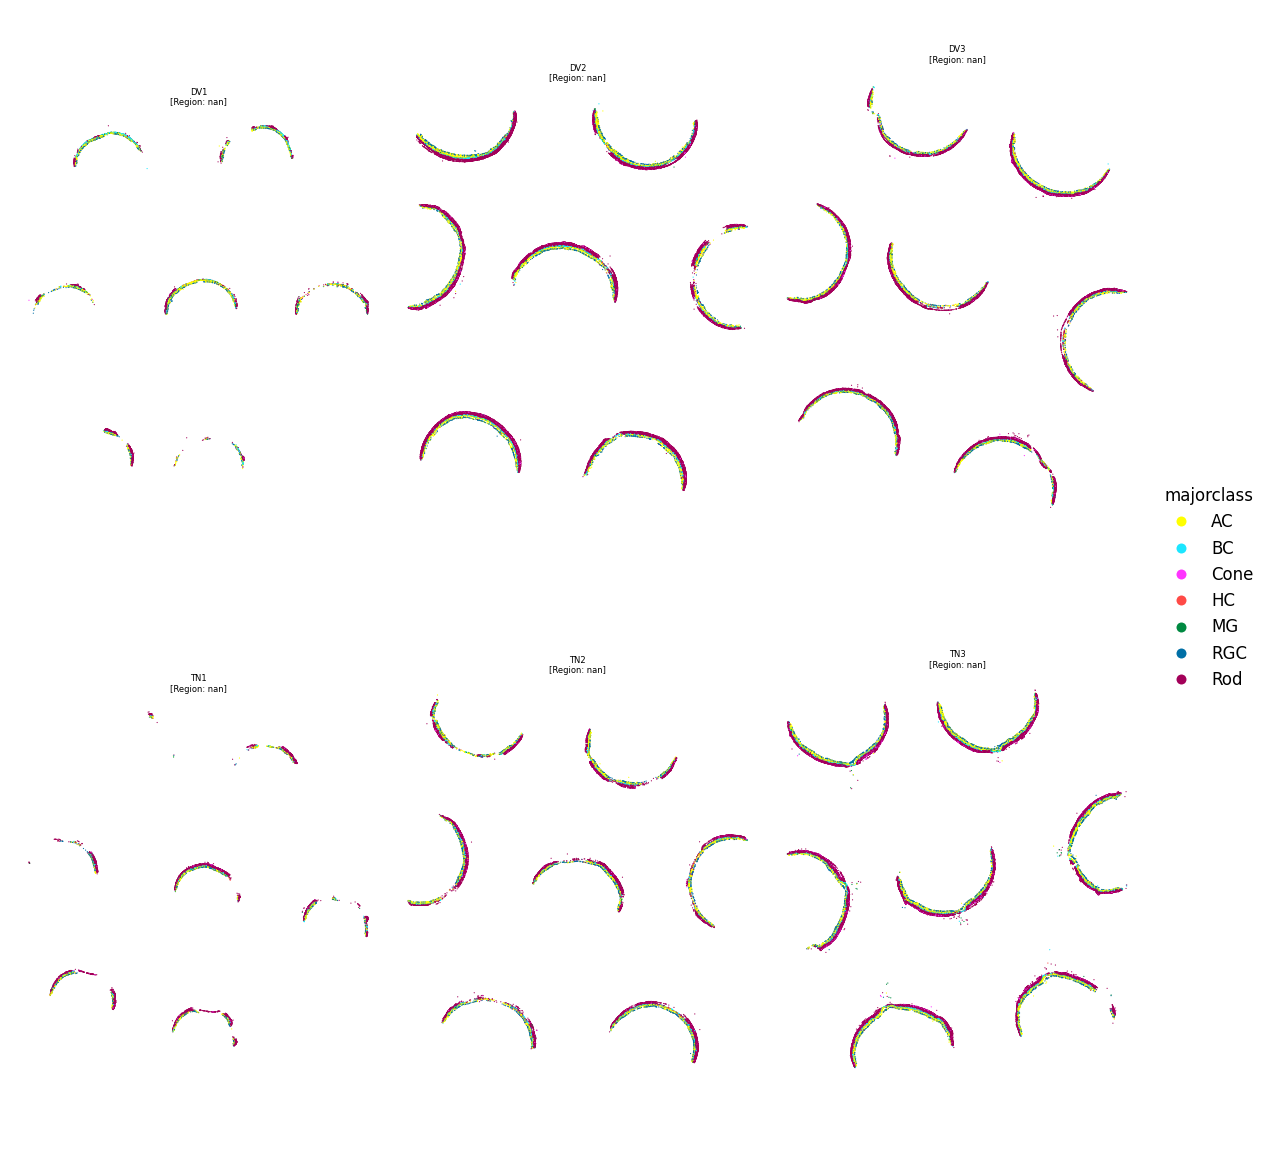

In [42]:
plot_spatial_compact_fast(      
    ad,
    color='majorclass',
    groupby='donor_id',
    spot_size=0.5,
    cols=3,
    height=10,
    background="white",
    dpi=120,
)
